# Lab 7.05 - Time series analysis

In [1]:
# Package imports
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation


### Exercise 5 - Alcoholic beverages sales

The file US Retail.csv contains monthly retail sales of beer, wine, and liquor at U.S. liquor stores.

- Is seasonality present in these data?
- Create a time series chart of the data. Based on what you see, which of the exponential smoothing models do you think should be used for forecasting? Why?
- Split the dataset in a train (1992-01-01 up to and including 2008-12-01) and test set (2009-01-01 up to and including 2009-12-01)  
- Create and train the model. 
- Predict the values for 2009.
- Create a plot with the train data, the fitted values, the test data and the predicted values.
- Calculate MAE

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/US%20Retail.csv', delimiter = ";", parse_dates=['Month']).set_index(['Month'])
data.head()

,Total Sales
Month,
1992-01-01,1519
1992-02-01,1551
1992-03-01,1606
1992-04-01,1686
1992-05-01,1834


In [4]:
train = data.loc['1992-01-01':'2008-12-01']
test = data.loc['2009-01-01':'2009-12-01']

<Axes: xlabel='Month'>

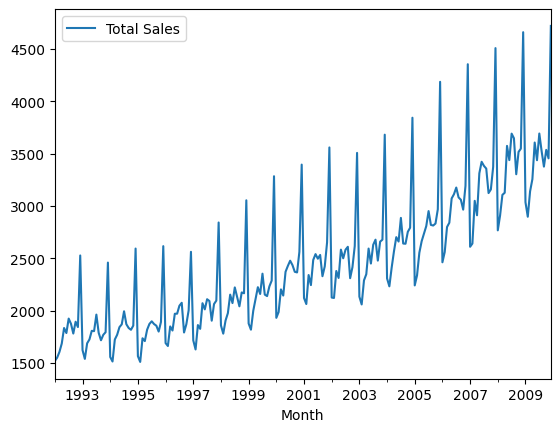

In [3]:
data.plot(y='Total Sales')

In [10]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error
model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12)
fit = model.fit()
forecast = fit.forecast(len(test))




mae = mean_absolute_error(test, forecast)
print(f"Mean Absolute Error (MAE): {mae}")

Mean Absolute Error (MAE): 163.3275394957834


/home/seppevo/repo/dsai-labs/.venv/lib64/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


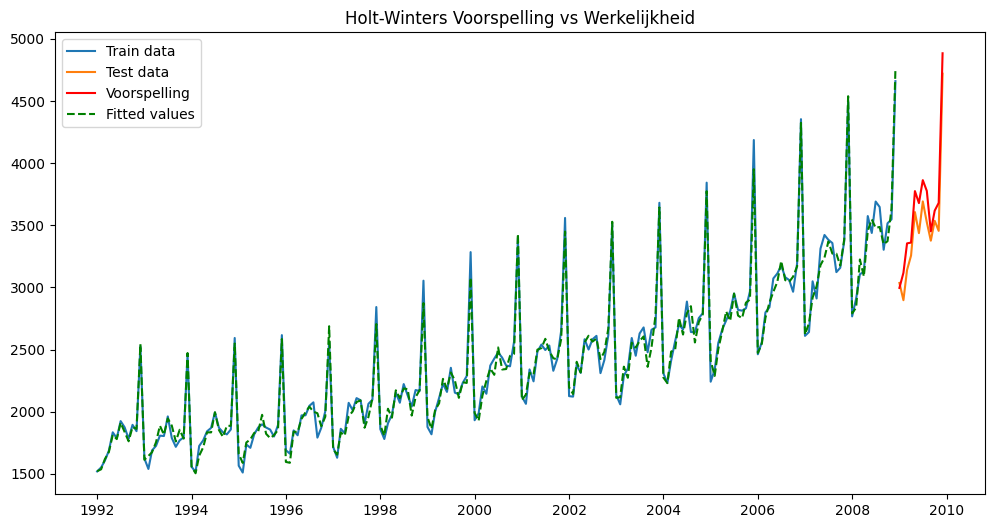

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Train data')
plt.plot(test.index, test, label='Test data')
plt.plot(test.index, forecast, label='Voorspelling', color='red')
plt.plot(train.index, fit.fittedvalues, label='Fitted values', color='green', linestyle='--')
plt.legend()
plt.title("Holt-Winters Voorspelling vs Werkelijkheid")
plt.show()

## Source
Business Analytics Data Analysis & Decision Making 